# Practical 6

Anna Chen (yc4406)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load('P6_data.npz')

u = data['u']
v = data['v']
x_velocity = data['x_velocity']
y_velocity = data['y_velocity']

bed_elevation = data['bed_elevation']
surface_elevation = data['surface_elevation']
surface_slope = data['surface_slope']
ice_thickness = data['ice_thickness']
x_bedmap = data['x_bedmap']
y_bedmap = data['y_bedmap']

In [3]:
print(f"shape of x_velocity is {x_velocity.shape}")
print(f"shape of u is {u.shape}")
print(f"shape of y_velocity is {y_velocity.shape}")
print(f"shape of v is {v.shape}")

shape of x_velocity is (1160,)
shape of u is (1120, 1160)
shape of y_velocity is (1120,)
shape of v is (1120, 1160)


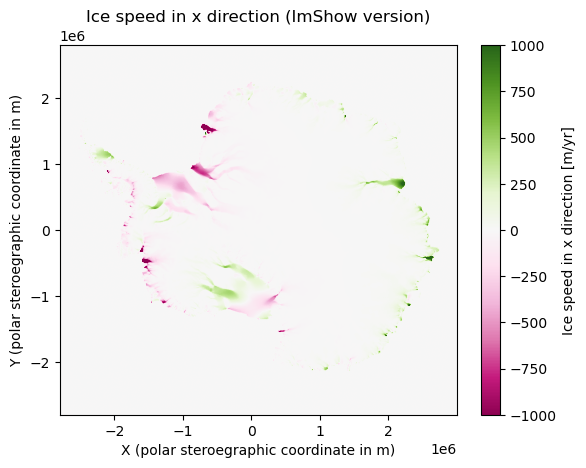

In [4]:
# Plot the horizontal velocity u across x_velocity and y_velocity grids
import matplotlib.cm as cm
# Use imshow to plot the u map
plt.imshow(u[:, :], origin='lower', 
           extent=[x_velocity.min(), x_velocity.max(), y_velocity.min(), y_velocity.max()], 
           vmin=-1000, vmax=1000,
           cmap='PiYG', aspect='auto')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Ice speed in x direction [m/yr]')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Ice speed in x direction (ImShow version)')

plt.show()

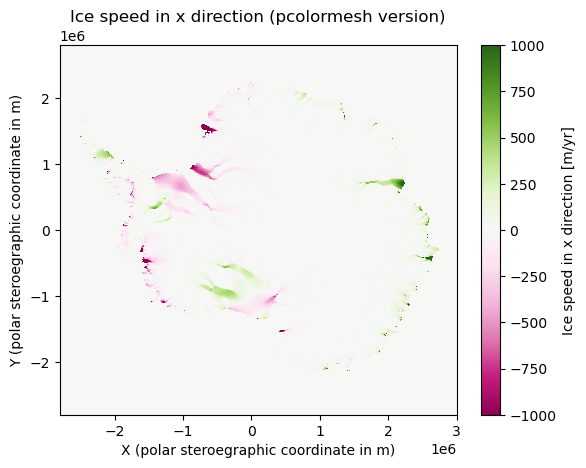

In [5]:
# Another option is to use pcolormesh (good for low resolution datasets)
plt.pcolormesh(x_velocity, y_velocity, u, clim = (-1000,1000), cmap = 'PiYG')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Ice speed in x direction [m/yr]')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Ice speed in x direction (pcolormesh version)')

plt.show()

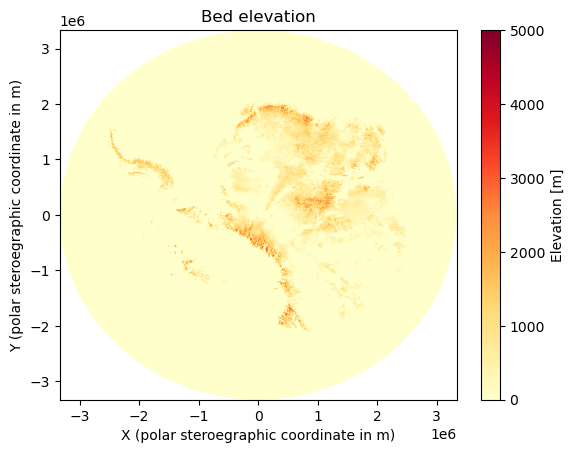

In [6]:
# Use pcolormesh to plot bed elevation
plt.pcolormesh(x_bedmap, y_bedmap, bed_elevation, clim = (0,5000), cmap = 'YlOrRd')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Elevation [m]')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Bed elevation')

plt.show()

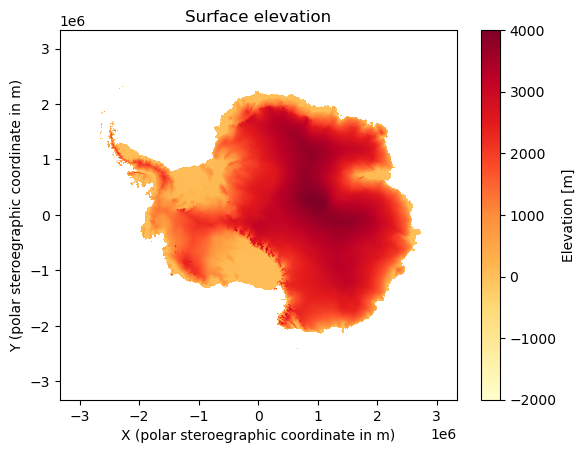

In [ ]:
# Use pcolormesh to plot surface elevation
plt.pcolormesh(x_bedmap, y_bedmap, surface_elevation, clim = (-2000,4000), cmap = 'YlOrRd')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Elevation [m]')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Surface elevation')

plt.show()

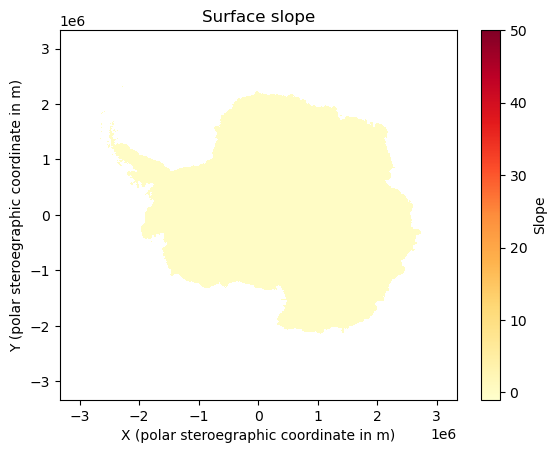

In [ ]:
# Use pcolormesh to plot surface slope
plt.pcolormesh(x_bedmap, y_bedmap, surface_slope, clim = (-1,1), cmap = 'YlOrRd')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Slope')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Surface slope')

plt.show()

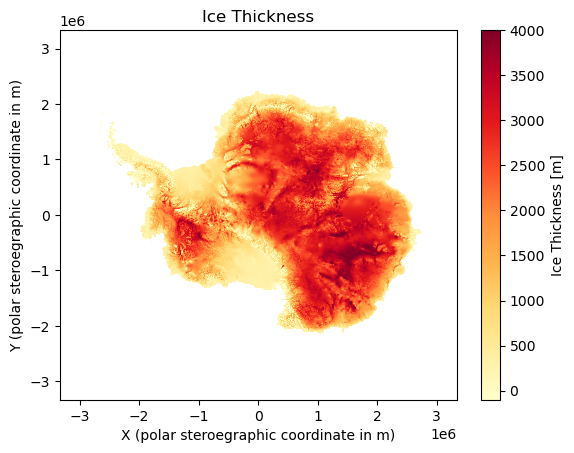

In [ ]:
# Use pcolormesh to plot ice thickness
plt.pcolormesh(x_bedmap, y_bedmap, ice_thickness, clim = (-100,4000), cmap = 'YlOrRd')

# Add a color bar to show the mapping of 'z' values to colors
plt.colorbar(label='Ice Thickness [m]')

# Add labels and title
plt.xlabel('X (polar steroegraphic coordinate in m)')
plt.ylabel('Y (polar steroegraphic coordinate in m)')
plt.title('Ice Thickness')

plt.show()

In [ ]:
def find_speed(u,v):
    return np.sqrt(u**2 + v**2)

def speed_section(x1, x2, y1, y2, N):
    """
    Find the speed of the given section from (x1,y1) to (x2,y2)

    Parameters:
    ---------------
    x1: float
        Initial point's x coordinate
    y1: float
        Initial point's y coordinate
    x2: float
        Final point's x coordinate
    y2: float
        Final point's y coordinate
    N: float
        Number of points to sample inbetween initial and final points
    
    Return:
    ---------------
    distance: np array
        The linearly interpolated distance in m across (x2, y2) and (x1, y1)
    speed_value: np array
        The speed at each (x_i, y_i) location in m/yr
    """
    x_i = np.linspace(x1, x2, N)
    y_i = np.linspace(y1, y2, N)

    distance = np.empty(N)
    u_value = np.empty(N)
    v_value = np.empty(N)
    speed_value = np.empty(N)

    for j in range(N):
        # Find the exact x coordinate value in x_velocity based on every given x in x_i
        abs_error_x = np.absolute(x_velocity - x_i[j])
        min_index_x = np.argmin(abs_error_x)

        # Find the exact y coordinate value in y_velocity based on every given y in y_i
        abs_error_y = np.absolute(y_velocity - y_i[j])
        min_index_y = np.argmin(abs_error_y)

        # Find distance from (x1, y1)
        diff_x = (x_i[j] - x1)
        diff_y = (y_i[j] - y1)
        distance[j] = np.sqrt(diff_x**2 + diff_y**2)

        # Find speed at given indexes in u and v
        u_value = u[min_index_x, min_index_y]
        v_value = v[min_index_x, min_index_y]
        speed_value[j] = find_speed(u_value, v_value)
    
    return distance, speed_value

The speed [m/yr] across the given section is 
 [ 5.55193101  4.70514602  5.08701327  4.54942762  5.04443071  4.7998707
  4.7998707   4.62629093  4.4604811   3.27462571  2.77481063  2.77481063
  2.21626628  3.227812    3.02293646  3.46687469  3.46687469  3.04283737
  3.30742497  2.74698838  3.24004023  3.24004023  2.88333662  2.99295046
  2.93691283  2.51836321  2.36863351  1.94150745  1.90767722  1.58326343
  1.07382018  1.10006765  1.25837348  1.00234092  1.32053059  1.60613698
  1.74221146  1.94849731  2.10102544  2.56315036  1.78805079  1.48603042
  1.46627322  2.29379059  2.36354528  2.82305485  2.87574094  2.69111435
  3.1815847   2.27120273  3.00315733  2.56401207  3.08340581  4.08998612
  3.80246658  3.68252574  4.99121361  3.39802796  4.38384666  3.66879769
  1.86029692  2.19423031  2.32356325  2.0164397   3.22837355  4.34499017
  3.70080093  5.2342298   6.72857541  5.98548134  6.59864536  6.75254053
  6.08543396  7.99671602  7.82461641  7.46906312  8.38568459  6.87100759
  3.7

Text(0, 0.5, 'Speed [m/yr]')

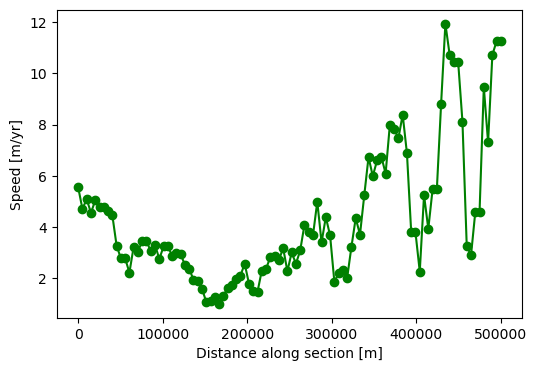

In [ ]:
x1, x2, y1, y2 = 1.1 * 10**6, 1.4 * 10**6, 1.5 * 10**6, 1.9 * 10**6

print(f"The speed [m/yr] across the given section is \n {speed_section(x1, x2, y1, y2, 100)[1]}")

# Plot speed over distance along section
figure, axes = plt.subplots(figsize=(6,4))
axes.plot(speed_section(x1, x2, y1, y2, 100)[0], speed_section(x1, x2, y1, y2, 100)[1], 'go-')
axes.set_xlabel('Distance along section [m]')
axes.set_ylabel('Speed [m/yr]')

In [ ]:
# When z=0 at the surface
# u = 2A(rho g alpha H)^n (H / (n+1))

def interpolate_and_plot(x,y,field,x_i, y_i):
    interp = scipy.interpolate.RegularGridInterpolator((y,x),field)
    interpolated_values = interp((y_i, x_i))